# Surface plasmon illustration with PyMoosh

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import PyMoosh as PM
from PyMoosh.modes import guided_modes, complex_map

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

In [2]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
w = 5690*8.118 # the waist before reflection corresponding to the experimental setup defined

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
h_Au = 47
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000*5, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

BK7 = PM.Material("BK7")
print(np.sqrt(np.abs(BK7.get_permittivity(wavelength))))

Pixels horizontally: 46191
Incidence in degrees: 73.38000000000001
H//, TM, p polarization
Pixels vertically: 2104


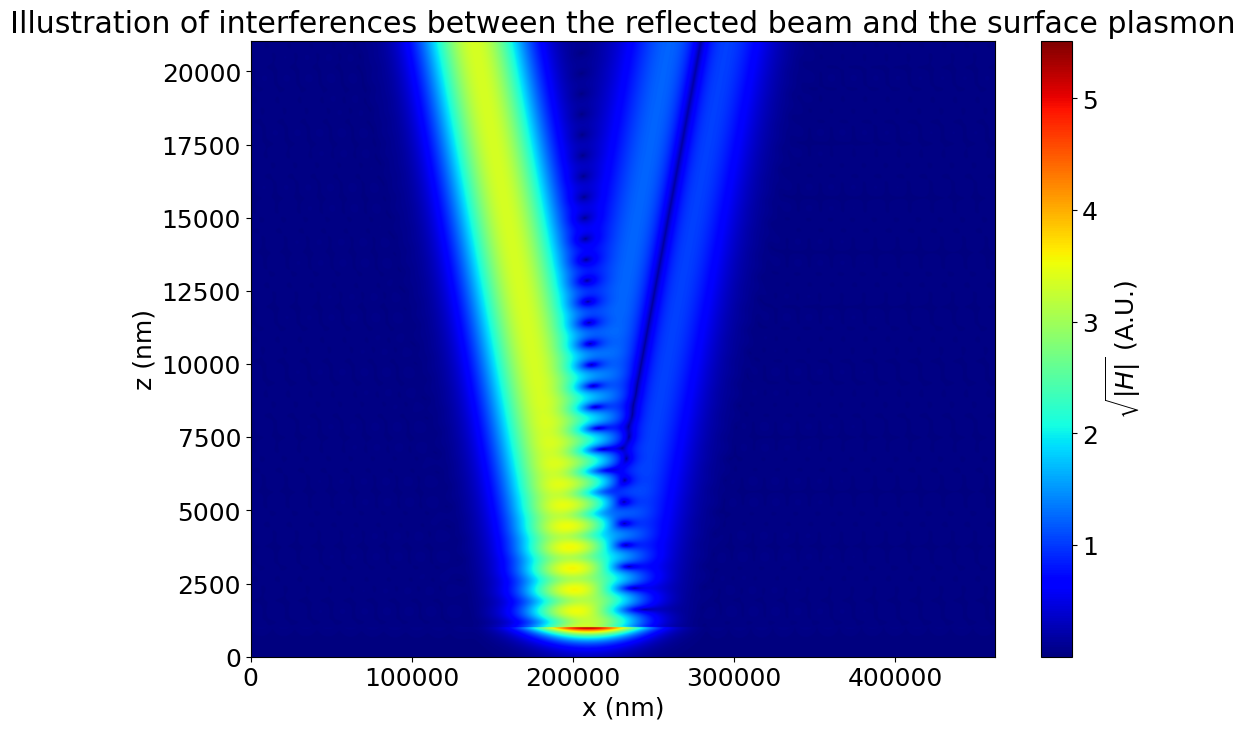

In [3]:
window = PM.Window(w*10, 0.3,10 , 10)
beam = PM.Beam(wavelength, 73.38*np.pi/180, 1, w/2)
H = PM.field(structure,beam,window)

plt.figure(figsize=(12, 8))
plt.imshow(np.abs(H)**0.5,cmap='jet',extent=[0,window.width,0,sum(structure.thickness)],aspect='auto')
# plt.imshow(np.real(H)*(np.real(H)>0),cmap='jet',extent=[0,window.width,0,sum(structure.thickness)],aspect='auto')
# plt.clim(0,0.04*np.max(np.abs(H)))
plt.xlabel('x (nm)')
plt.ylabel('z (nm)')
plt.title('Illustration of interferences between the reflected beam and the surface plasmon')
cbar=plt.colorbar()
cbar.set_label(r'$\sqrt{|H|}$ (A.U.)');

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/surface_plasmon_illustration.{file_ext}", bbox_inches="tight")

In [28]:
mat = ["BK7",Cr,Au,1.33**2]
thickness = [4000, 2, h_Au]  # thickness of each layer
stack = [0, 1, 2]
structure = PM.Structure(mat, stack, thickness, verbose=False)

[np.complex128(1.6797495965728146+0.08836892553292074j)]


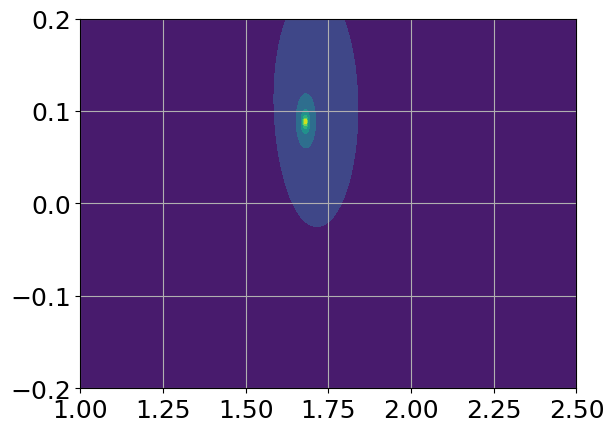

In [ ]:
X,Y,T = complex_map(structure,wavelength,1,[1.,2.5],[-0.2,0.2],300,300)
plt.contourf(X,Y,np.sqrt(np.real(T)))
plt.grid(True);

l_modes = guided_modes(structure,wavelength,1,1.5,2.0)
print(l_modes)